# PA / PB1 binder candidates — analysis report

Self-contained notebook: reads `summary_best_candidates.csv` and produces:
- ColabDesign vs AF3 scatter plots
- Metric correlation heatmap
- Per-protocol statistics
- Rank table and bump chart
- Sequence-space PCA + t-SNE coloured by AF3 iPTM and energy

**No external dependencies beyond the CSV file.**

In [2]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='tab10')
pd.set_option('display.float_format', '{:.3f}'.format)

In [3]:
# ── adjust if running from a different directory ───────────────────────────────
CSV_PATH = pathlib.Path('../results/summary_best_candidates.csv')
# ──────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df)} candidates  |  columns: {list(df.columns)}')
df.head()

Loaded 60 candidates  |  columns: ['seq', 'protocol', 'model', 'name', 'colab_iptm', 'colab_ptm', 'colab_plddt', 'energy', 'af3_iptm_cross', 'af3_iptm', 'af3_ptm', 'af3_ranking_score', 'af3_has_clash', 'af3_frac_disordered', 'af3_folder']


,seq,protocol,model,name,colab_iptm,colab_ptm,colab_plddt,energy,af3_iptm_cross,af3_iptm,af3_ptm,af3_ranking_score,af3_has_clash,af3_frac_disordered,af3_folder
0,MDFNPWLLFLKVPAQ,seqs_aff_alberto_darren_6best,af2,custom/seqs_aff_alberto_darren_6best_0,0.189,0.888,0.308,-1.017,0.970,0.970,0.880,1.010,0.000,0.120,fold_2026_04_16_mdfnpwllflkvpaq
1,VDFNPWLLFLKVPAQ,seqs_aff_alberto_darren_6best,af2,custom/seqs_aff_alberto_darren_6best_1,0.216,0.890,0.308,-1.130,0.970,0.970,0.880,1.010,0.000,0.120,fold_2026_04_16_vdfnpwllflkvpaq
2,IDFNPYLLFLKVPAQ,seqs_aff_alberto_darren_6best,af2,custom/seqs_aff_alberto_darren_6best_2,0.202,0.889,0.296,0.921,0.970,0.970,0.880,1.010,0.000,0.120,fold_2026_04_16_idfnpyllflkvpaq
3,MDWNPLLLHLKRPAQ,seqs_aff_alberto_darren_6best,af2,custom/seqs_aff_alberto_darren_6best_3,0.209,0.889,0.328,3.179,0.920,0.920,0.880,0.970,0.000,0.120,fold_2026_04_16_mdwnplllhlkrpaq
4,VDYNPWLLFLRKPKQ,seqs_aff_alberto_darren_6best,af2,custom/seqs_aff_alberto_darren_6best_4,0.286,0.893,0.353,1.107,0.910,0.910,0.880,0.970,0.000,0.120,fold_2026_04_16_vdynpwllflrkpkq


## 1. Data overview

In [4]:
metric_cols = [c for c in [
    'colab_iptm', 'colab_ptm', 'colab_plddt', 'energy',
    'af3_iptm_cross', 'af3_iptm', 'af3_ptm', 'af3_ranking_score',
] if c in df.columns]

display_cols = ['seq', 'protocol'] + metric_cols
df[display_cols].sort_values(
    'af3_iptm_cross' if 'af3_iptm_cross' in df.columns else metric_cols[0],
    ascending=False, na_position='last'
)

,seq,protocol,colab_iptm,colab_ptm,colab_plddt,energy,af3_iptm_cross,af3_iptm,af3_ptm,af3_ranking_score
0,MDFNPWLLFLKVPAQ,seqs_aff_alberto_darren_6best,0.189,0.888,0.308,-1.017,0.970,0.970,0.880,1.010
1,VDFNPWLLFLKVPAQ,seqs_aff_alberto_darren_6best,0.216,0.890,0.308,-1.130,0.970,0.970,0.880,1.010
2,IDFNPYLLFLKVPAQ,seqs_aff_alberto_darren_6best,0.202,0.889,0.296,0.921,0.970,0.970,0.880,1.010
3,MDWNPLLLHLKRPAQ,seqs_aff_alberto_darren_6best,0.209,0.889,0.328,3.179,0.920,0.920,0.880,0.970
4,VDYNPWLLFLRKPKQ,seqs_aff_alberto_darren_6best,0.286,0.893,0.353,1.107,0.910,0.910,0.880,0.970
5,IDYNPYLLFLKQPKQ,seqs_aff_alberto_darren_6best,0.211,0.889,0.311,-1.151,0.900,0.900,0.880,0.950
6,AISGPALEVLYCIFC,gen_energy_C,0.678,0.909,0.539,-6.437,0.820,0.820,0.860,0.880
7,SHGYVYDALWNMEVL,opt_anneal_energy_C,0.495,0.902,0.410,-2.916,0.820,0.820,0.860,0.880
8,AISGPALEVLYCIFC,gen_energy_C,0.678,0.901,0.501,-6.437,0.820,0.820,0.860,0.880
9,AISGPALEVLYCIFC,gen_energy_C,0.678,0.909,0.539,-6.437,0.820,0.820,0.860,0.880


## 2. ColabDesign vs AF3 scatter plots

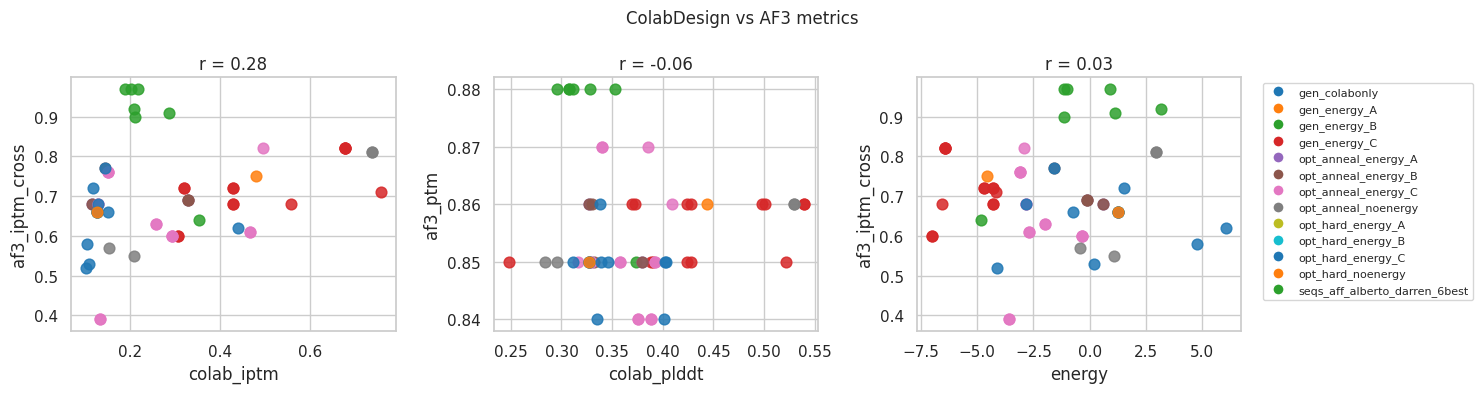

In [5]:
pairs = [
    ('colab_iptm',  'af3_iptm_cross'),
    ('colab_plddt', 'af3_ptm'),
    ('energy',      'af3_iptm_cross'),
]
pairs = [(x, y) for x, y in pairs
         if x in df.columns and y in df.columns and df[y].notna().any()]

protocols = sorted(df['protocol'].dropna().unique())
palette   = dict(zip(protocols, sns.color_palette('tab10', len(protocols))))

fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
if len(pairs) == 1:
    axes = [axes]

for ax, (xcol, ycol) in zip(axes, pairs):
    df_pair = df.dropna(subset=['protocol', xcol, ycol])
    for proto, grp in df_pair.groupby('protocol'):
        ax.scatter(grp[xcol], grp[ycol], label=proto,
                   color=palette.get(proto, 'grey'), s=60, alpha=0.85)
    r = df[[xcol, ycol]].dropna().corr().iloc[0, 1]
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    ax.set_title(f'r = {r:.2f}')

handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=palette[p], label=p, markersize=8)
           for p in protocols]
axes[-1].legend(handles=handles, bbox_to_anchor=(1.05, 1),
                loc='upper left', fontsize=8)
fig.suptitle('ColabDesign vs AF3 metrics', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Metric correlation heatmap

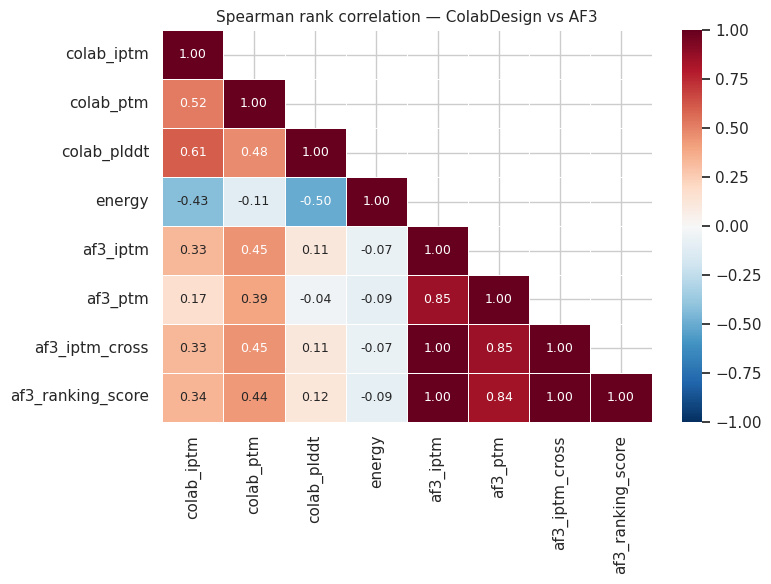

In [6]:
corr_cols = [c for c in [
    'colab_iptm', 'colab_ptm', 'colab_plddt', 'energy',
    'af3_iptm', 'af3_ptm', 'af3_iptm_cross', 'af3_ranking_score',
] if c in df.columns and df[c].notna().any()]

corr = df[corr_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask,
            linewidths=0.4, annot_kws={'size': 9})
ax.set_title('Spearman rank correlation — ColabDesign vs AF3', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Protocol statistics

In [7]:
stat_cols = [c for c in ['colab_iptm', 'af3_iptm_cross', 'energy'] if c in df.columns]
proto_df  = df.dropna(subset=['protocol'])

print('--- Mean ---')
display(proto_df.groupby('protocol')[stat_cols].mean().round(3))
print('--- Max ---')
display(proto_df.groupby('protocol')[stat_cols].max().round(3))
print('--- Count ---')
display(proto_df.groupby('protocol')[stat_cols[0]].count().rename('n').to_frame())

--- Mean ---


,colab_iptm,af3_iptm_cross,energy
protocol,,,
gen_colabonly,0.441,0.620,6.069
gen_energy_A,0.481,0.750,-4.553
gen_energy_B,0.354,0.640,-4.850
gen_energy_C,0.500,0.722,-5.512
opt_anneal_energy_A,0.222,0.685,0.235
opt_anneal_energy_B,0.229,0.708,-0.311
opt_anneal_energy_C,0.253,0.635,-2.354
opt_anneal_noenergy,0.460,0.685,1.631
opt_hard_energy_A,0.125,0.660,1.257


--- Max ---


,colab_iptm,af3_iptm_cross,energy
protocol,,,
gen_colabonly,0.441,0.620,6.069
gen_energy_A,0.481,0.750,-4.553
gen_energy_B,0.354,0.640,-4.850
gen_energy_C,0.759,0.820,-4.150
opt_anneal_energy_A,0.329,0.690,0.602
opt_anneal_energy_B,0.329,0.770,0.602
opt_anneal_energy_C,0.495,0.820,-0.352
opt_anneal_noenergy,0.739,0.810,2.943
opt_hard_energy_A,0.125,0.660,1.257


--- Count ---


,n
protocol,
gen_colabonly,1
gen_energy_A,1
gen_energy_B,1
gen_energy_C,14
opt_anneal_energy_A,2
opt_anneal_energy_B,4
opt_anneal_energy_C,15
opt_anneal_noenergy,4
opt_hard_energy_A,1


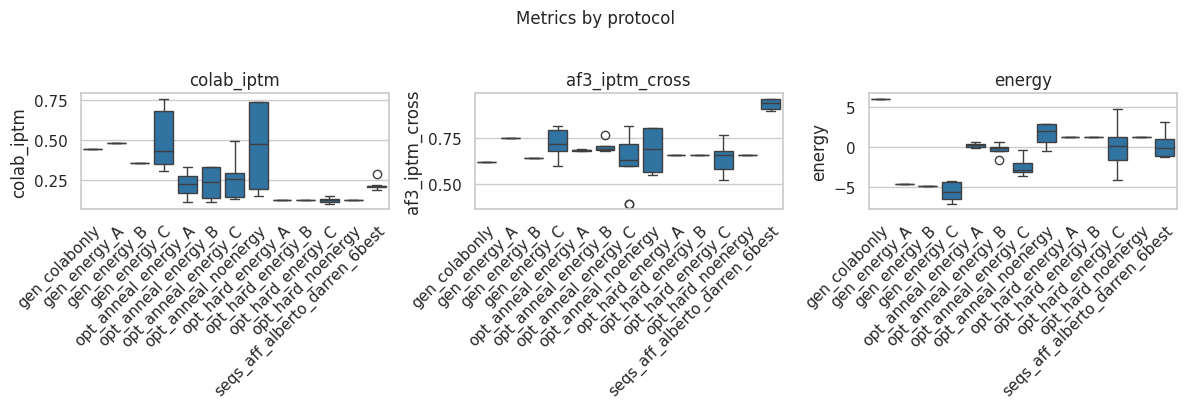

In [8]:
# Box plots per protocol
box_cols = [c for c in ['colab_iptm', 'af3_iptm_cross', 'energy'] if c in df.columns]
proto_order = sorted(proto_df['protocol'].unique())

fig, axes = plt.subplots(1, len(box_cols), figsize=(4 * len(box_cols), 4), sharey=False)
if len(box_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=proto_df, x='protocol', y=col, ax=ax, order=proto_order)
    ax.set_title(col); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
fig.suptitle('Metrics by protocol', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Rank table and comparison

In [9]:
rank_metrics = [c for c in ['af3_iptm_cross', 'colab_iptm'] if c in df.columns]

df_rank = df[['seq', 'protocol'] + rank_metrics].dropna(subset=rank_metrics).copy()
for col in rank_metrics:
    df_rank[f'rank_{col}'] = df_rank[col].rank(ascending=False).astype(int)

rank_cols = [f'rank_{c}' for c in rank_metrics]
print(f'{len(df_rank)} sequences with all rank metrics')
df_rank[['seq', 'protocol'] + rank_metrics + rank_cols].sort_values(rank_cols[0])

60 sequences with all rank metrics


,seq,protocol,af3_iptm_cross,colab_iptm,rank_af3_iptm_cross,rank_colab_iptm
0,MDFNPWLLFLKVPAQ,seqs_aff_alberto_darren_6best,0.970,0.189,2,37
1,VDFNPWLLFLKVPAQ,seqs_aff_alberto_darren_6best,0.970,0.216,2,32
2,IDFNPYLLFLKVPAQ,seqs_aff_alberto_darren_6best,0.970,0.202,2,36
3,MDWNPLLLHLKRPAQ,seqs_aff_alberto_darren_6best,0.920,0.209,4,34
4,VDYNPWLLFLRKPKQ,seqs_aff_alberto_darren_6best,0.910,0.286,5,29
5,IDYNPYLLFLKQPKQ,seqs_aff_alberto_darren_6best,0.900,0.211,6,33
6,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,9,6
7,SHGYVYDALWNMEVL,opt_anneal_energy_C,0.820,0.495,9,9
8,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,9,4
9,AISGPALEVLYCIFC,gen_energy_C,0.820,0.678,9,6


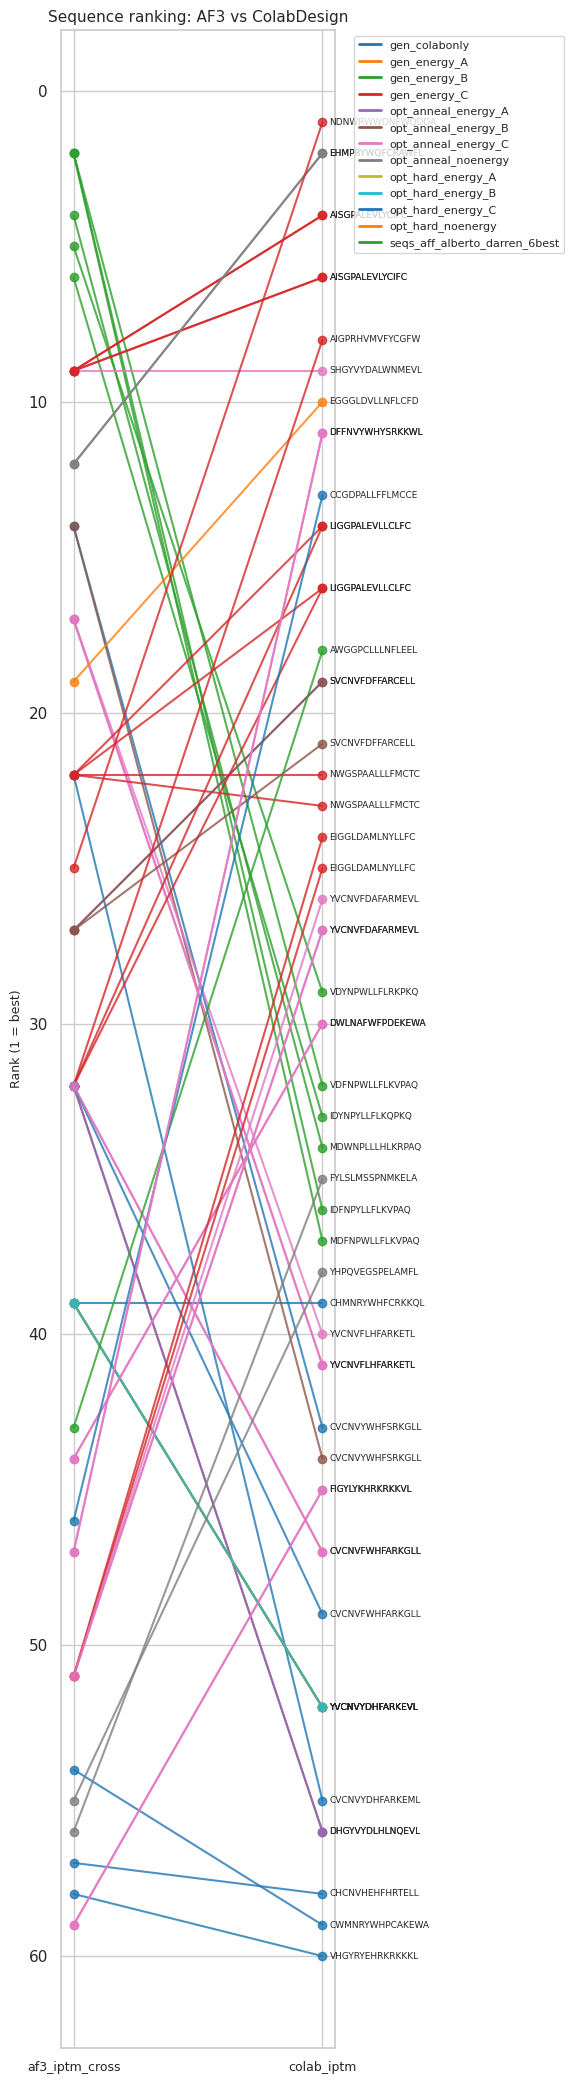

In [10]:
# Bump chart
if len(rank_metrics) >= 2 and len(df_rank) > 0:
    fig, ax = plt.subplots(figsize=(max(6, len(rank_metrics) * 2.5),
                                    max(5, len(df_rank) * 0.35)))
    x_pos = list(range(len(rank_metrics)))

    for _, row in df_rank.iterrows():
        ranks = [row[f'rank_{c}'] for c in rank_metrics]
        color = palette.get(row['protocol'], 'grey')
        ax.plot(x_pos, ranks, marker='o', color=color, alpha=0.8, lw=1.5)
        ax.annotate(row['seq'], (x_pos[-1], ranks[-1]),
                    fontsize=6.5, va='center',
                    xytext=(5, 0), textcoords='offset points')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(rank_metrics, fontsize=9)
    ax.invert_yaxis()
    ax.set_ylabel('Rank (1 = best)', fontsize=9)
    ax.set_title('Sequence ranking: AF3 vs ColabDesign', fontsize=11)
    handles = [plt.Line2D([0],[0], color=c, lw=2, label=p) for p, c in palette.items()]
    ax.legend(handles=handles, fontsize=8,
              bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data for bump chart.')

## 6. Sequence space — PCA + t-SNE

Each peptide is integer-encoded (one position → one integer 1–20). PCA decorrelates
the representation; t-SNE maps to 2-D. Points coloured by AF3 iPTM and energy.

In [16]:
# ── Parameters ────────────────────────────────────────────────────────────────
N_PCA        = 5
PERPLEXITY   = 10    # reduce if n_seqs < 60
LEARNING_RATE = 'auto'
RANDOM_STATE  = 42
# ──────────────────────────────────────────────────────────────────────────────

AA_ORDER  = 'ACDEFGHIKLMNPQRSTVWY'
AA_TO_INT = {aa: i + 1 for i, aa in enumerate(AA_ORDER)}

def encode_sequence(seq: str, length: int) -> np.ndarray:
    vec = np.zeros(length, dtype=np.float32)
    for i, aa in enumerate(seq[:length]):
        vec[i] = AA_TO_INT.get(aa, 0)
    return vec

df_ok   = df[df['seq'].notna()].copy()
SEQ_LEN = int(df_ok['seq'].str.len().mode()[0])
df_ok   = df_ok[df_ok['seq'].str.len() == SEQ_LEN].reset_index(drop=True)
print(f'Sequence length: {SEQ_LEN}  |  sequences for PCA/t-SNE: {len(df_ok)}')

X_raw    = np.stack([encode_sequence(s, SEQ_LEN) for s in df_ok['seq']])
X_scaled = StandardScaler().fit_transform(X_raw)

Sequence length: 15  |  sequences for PCA/t-SNE: 60


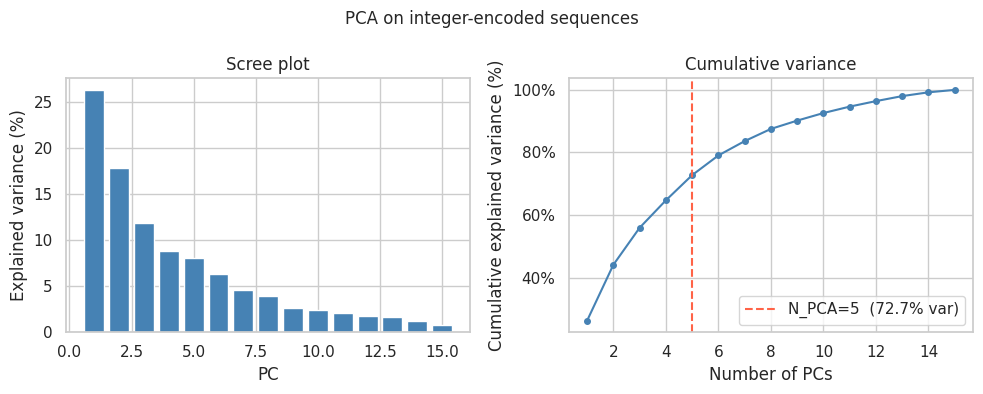

PCA: 15 → 5 dims  (72.7% variance retained)


In [17]:
# PCA scree + cumulative variance
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
evr      = pca_full.explained_variance_ratio_
cumevr   = np.cumsum(evr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(range(1, len(evr)+1), evr * 100, color='steelblue')
ax1.set_xlabel('PC'); ax1.set_ylabel('Explained variance (%)')
ax1.set_title('Scree plot')

ax2.plot(range(1, len(evr)+1), cumevr * 100, marker='o', color='steelblue', ms=4)
ax2.axvline(N_PCA, color='tomato', linestyle='--',
            label=f'N_PCA={N_PCA}  ({cumevr[N_PCA-1]*100:.1f}% var)')
ax2.legend()
ax2.set_xlabel('Number of PCs')
ax2.set_ylabel('Cumulative explained variance (%)')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_title('Cumulative variance')
plt.suptitle('PCA on integer-encoded sequences', fontsize=12)
plt.tight_layout()
plt.show()

n_pca_actual = min(N_PCA, X_scaled.shape[1])
X_pca = PCA(n_components=n_pca_actual, random_state=RANDOM_STATE).fit_transform(X_scaled)
print(f'PCA: {X_scaled.shape[1]} → {n_pca_actual} dims  ({cumevr[n_pca_actual-1]*100:.1f}% variance retained)')

In [18]:
# t-SNE
perp = min(PERPLEXITY, len(X_pca) - 1)
tsne = TSNE(n_components=2, perplexity=perp,
            learning_rate=LEARNING_RATE,
            random_state=RANDOM_STATE, init='pca', verbose=1)
X_tsne = tsne.fit_transform(X_pca)
df_ok  = df_ok.assign(tsne_x=X_tsne[:, 0], tsne_y=X_tsne[:, 1])
print(f't-SNE done  |  KL divergence: {tsne.kl_divergence_:.4f}')

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 60 samples in 0.000s...
[t-SNE] Computed neighbors for 60 samples in 0.010s...
[t-SNE] Computed conditional probabilities for sample 60 / 60
[t-SNE] Mean sigma: 1.561906
[t-SNE] KL divergence after 250 iterations with early exaggeration: 53.729641
[t-SNE] KL divergence after 1000 iterations: -0.610890
t-SNE done  |  KL divergence: -0.6109


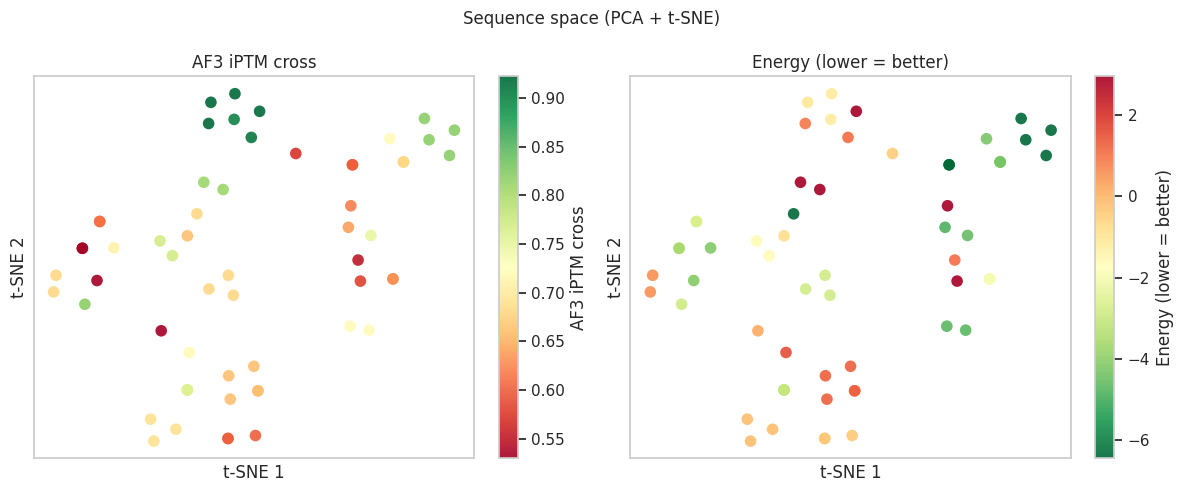

In [19]:
# t-SNE coloured by AF3 iPTM and energy
color_metrics = [
    ('af3_iptm_cross', 'RdYlGn',   'AF3 iPTM cross'),
    ('energy',         'RdYlGn_r', 'Energy (lower = better)'),
]
color_metrics = [(col, cmap, lbl) for col, cmap, lbl in color_metrics
                 if col in df_ok.columns and df_ok[col].notna().any()]

fig, axes = plt.subplots(1, len(color_metrics),
                          figsize=(6 * len(color_metrics), 5))
if len(color_metrics) == 1:
    axes = [axes]

for ax, (col, cmap, lbl) in zip(axes, color_metrics):
    vals = df_ok[col]
    sc = ax.scatter(
        df_ok['tsne_x'], df_ok['tsne_y'],
        c=vals, cmap=cmap, s=70, alpha=0.9,
        vmin=vals.quantile(0.05), vmax=vals.quantile(0.95),
        edgecolors='none',
    )
    plt.colorbar(sc, ax=ax, label=lbl, fraction=0.04)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.set_title(lbl)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Sequence space (PCA + t-SNE)', fontsize=12)
plt.tight_layout()
plt.show()

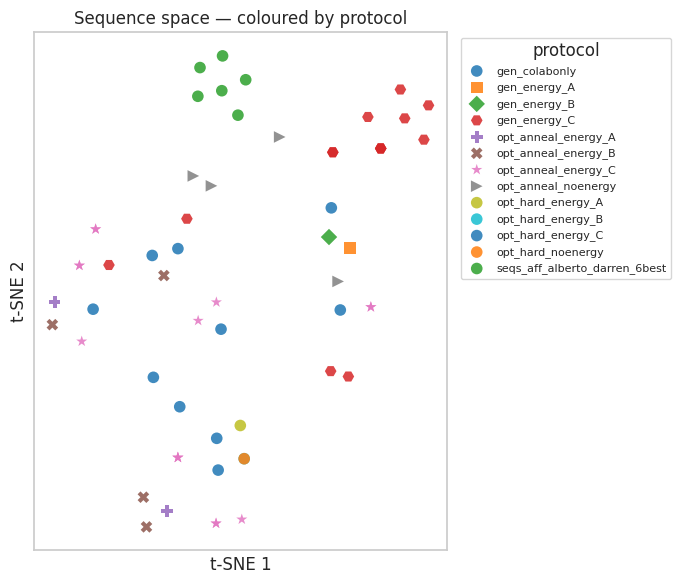

In [20]:
# t-SNE coloured by protocol
proto_palette = dict(zip(protocols, sns.color_palette('tab10', len(protocols))))
markers = ['o', 's', 'D', 'H', 'P', 'X', '*', '>']
proto_markers = dict(zip(protocols, markers))

fig, ax = plt.subplots(figsize=(7, 6))
for proto, grp in df_ok.dropna(subset=['protocol']).groupby('protocol'):
    ax.scatter(
        grp['tsne_x'], grp['tsne_y'],
        color=proto_palette.get(proto, 'grey'),
        marker=proto_markers.get(proto, 'o'),
        s=70, alpha=0.85, label=proto, edgecolors='none',
    )
ax.legend(title='protocol', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=8)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title('Sequence space — coloured by protocol')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()